**Building Fully Connected Neural Networks for Devnagari Handwritten Digit Classification.**

**Identifying the version of Keras**

In [ ]:
import tensorflow as tf
import keras

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


**4. Building a Simple Fully Connected Neural Network in Keras.**

Training set: (17031, 784), Labels: (17031, 10)
Testing set: (3000, 784), Labels: (3000, 10)


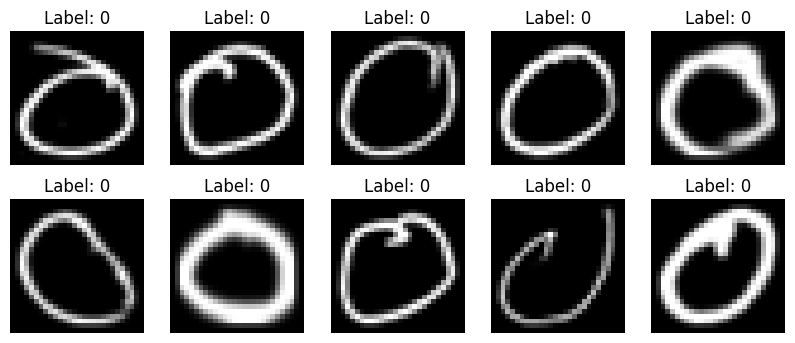

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

# Define dataset paths (UPDATED)
train_dir = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset/Test"

# Image size
img_height, img_width = 28, 28

# Function to load images and labels
def load_images_from_folder(folder):
    images = []
    labels = []

    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load and preprocess image
            img = Image.open(img_path).convert("L")
            img = img.resize((img_width, img_height))
            img = np.array(img) / 255.0

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load dataset
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

# Reshape for Keras (Dense model)
x_train = x_train.reshape(-1, img_height * img_width)
x_test  = x_test.reshape(-1, img_height * img_width)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test, num_classes=10)

# Print shapes
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images (FIXED INDEXING)
plt.figure(figsize=(10, 4))

for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')  # fixed quotes
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")

plt.show()

**Task 2: Build the FCN Model**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 10
input_shape = (28, 28, 1)

# Create Sequential Model
model = keras.Sequential([

    # Input Layer
    keras.layers.Input(shape=input_shape),

    # Flatten Layer (convert 2D image to 1D vector)
    keras.layers.Flatten(),

    # Hidden Layers
    keras.layers.Dense(64, activation='sigmoid'),   # 1st hidden layer
    keras.layers.Dense(128, activation='sigmoid'),  # 2nd hidden layer
    keras.layers.Dense(256, activation='sigmoid'),  # 3rd hidden layer

    # Output Layer (10 classes)
    keras.layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compile the Model

In [ ]:
model.compile(
    optimizer='adam',  # Optimizer for updating weights
    loss='categorical_crossentropy',  # Used because labels are one-hot encoded
    metrics=['accuracy']  # Evaluate model performance using accuracy
)

Task 4: Train the Model

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

num_classes = 10
model = keras.Sequential([

    keras.layers.Input(shape=(784,)),

    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),

    keras.layers.Dense(num_classes, activation='softmax')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Show summary
model.summary()

# MODEL TRAINING

# Training parameters
batch_size = 128
epochs = 20

# Callbacks: save best model & prevent overfitting
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="best_model.keras",
        monitor="val_loss",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    )
]

# Train the model
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4585 - loss: 1.6362 - val_accuracy: 0.0000e+00 - val_loss: 7.1307
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8332 - loss: 0.5215 - val_accuracy: 0.0000e+00 - val_loss: 7.9279
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9138 - loss: 0.2930 - val_accuracy: 0.0000e+00 - val_loss: 7.9426
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9432 - loss: 0.1980 - val_accuracy: 0.0000e+00 - val_loss: 7.7752
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9570 - loss: 0.1521 - val_accuracy: 0.0000e+00 - val_loss: 7.6632


**Task 5: Evaluate the Model**

In [ ]:
# Evaluate model
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

# Display results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6093 - loss: 2.0740
Test Loss: 2.0740
Test Accuracy: 60.93%


**Task 6: Save and Load the Model**

In [ ]:
# Save the model in .h5 formatb(archeticture, weight, optimizer)
model.save("devanagari_digit_recognition.h5")
print("Model saved successfully in .h5 format!")

from tensorflow.keras.models import load_model

# Load the model
loaded_model = load_model("devanagari_digit_recognition.h5")
print("Model loaded successfully!")

# Evaluate the loaded model on the test set
test_loss, test_accuracy = loaded_model.evaluate(x_test, y_test, verbose=1)

# Print results
print(f"Loaded Model Test Loss: {test_loss:.4f}")
print(f"Loaded Model Test Accuracy: {test_accuracy:.4f}")


Model saved successfully in .h5 format!
Model loaded successfully!
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6093 - loss: 2.0740
Loaded Model Test Loss: 2.0740
Loaded Model Test Accuracy: 0.6093


**Task 7: Predictions**

In [ ]:
# Make predictions on the test set
predictions = model.predict(x_test)

# Print predicted probabilities for the first 5 images
print("Predicted probabilities for the first 5 test images:")
print(predictions[:5])

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

# Print predicted labels for the first 5 test images
print("\nPredicted digit labels for the first 5 test images:")
print(predicted_labels[:5])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Predicted probabilities for the first 5 test images:
[[6.01649880e-01 4.01133075e-02 2.21629674e-03 1.83437287e-03
  1.47979707e-02 4.55944007e-03 5.82076721e-02 2.76067436e-01
  2.88253708e-04 2.65504903e-04]
 [6.40354455e-01 6.82029277e-02 1.97743298e-03 1.69194129e-03
  1.54015515e-02 3.56228929e-03 5.19723855e-02 2.16269940e-01
  2.96754006e-04 2.70334072e-04]
 [5.99503756e-01 3.74643020e-02 1.89207867e-03 1.54249300e-03
  1.06636276e-02 3.63984983e-03 6.08943105e-02 2.83915907e-01
  2.53456732e-04 2.30204038e-04]
 [5.80943823e-01 6.04844317e-02 2.40030349e-03 2.04330031e-03
  1.32286167e-02 3.97594459e-03 7.44393095e-02 2.61892974e-01
  3.10767209e-04 2.80466018e-04]
 [6.05650485e-01 3.99726070e-02 1.89172488e-03 1.55345851e-03
  1.06868995e-02 3.53099825e-03 6.10190555e-02 2.75205880e-01
  2.56426400e-04 2.32370672e-04]]

Predicted digit labels for the first 5 test images:
[0 0 0 0 0]
